# 📘 Course 1 Study Reference — Supervised Machine Learning: Regression and Classification
### Andrew Ng's Machine Learning Specialization — a complete, runnable study reference

**How to use this notebook**
- Run top-to-bottom (`Kernel → Restart & Run All`). Every cell is self-contained given the cells above it — no external data files needed.
- Each topic follows the same rhythm: **concept (what + why) → from-scratch NumPy implementation → scikit-learn equivalent → plot for intuition**.
- 🔧 **Reusable pattern** marks functions that can be lifted straight into a real ML project.

**Running example used throughout:** predicting **tool/bearing wear** from machine sensor data (operating hours, spindle load, temperature, vibration), and classifying whether a machined part **passes or fails QC** — the same problem shapes you'd meet in industrial predictive maintenance.

In [1]:
# --- Setup: run this first ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)                      # reproducibility: same "random" data every run
plt.rcParams['figure.figsize'] = (8, 5) # default plot size
plt.rcParams['axes.grid'] = True        # gridlines aid reading values off plots
print("Setup complete. NumPy", np.__version__)

Setup complete. NumPy 2.4.4


---
## 1. Supervised Learning Framing & Notation

**What:** Supervised learning = learning a function from **labeled examples**: you give the algorithm inputs $x$ *and* the "right answers" $y$, and it learns a mapping $f$ so that for a *new* $x$ it predicts $\hat{y} = f(x)$.

Two flavors in this course:

| Task | Output $y$ | Manufacturing example |
|---|---|---|
| **Regression** | continuous number | predict tool wear in mm from operating hours |
| **Classification** | discrete category (here: 0/1) | predict whether a part passes (1) or fails (0) QC |

**Notation (memorize this — the whole course is written in it):**

| Symbol | Meaning |
|---|---|
| $x$ | input feature (e.g. operating hours) |
| $y$ | target / label (e.g. measured wear) |
| $m$ | number of training examples |
| $(x^{(i)}, y^{(i)})$ | the $i$-th training example |
| $w, b$ | parameters the model *learns* — weight(s) and bias |
| $\hat{y}$ or $f_{w,b}(x)$ | the model's prediction |
| $n$ | number of features (once we go multi-feature) |

**Why it matters:** every formula later (cost, gradients, regularization) is stated in exactly these symbols. If $m$ vs $n$ or $x^{(i)}$ vs $x_j$ is fuzzy, the vectorized code in Section 5 will look like magic instead of translation.

**One more distinction that starts here and matters everywhere:** a **parameter** is learned from data by the algorithm ($w$, $b$); a **hyperparameter** is chosen by the practitioner before training (learning rate $\alpha$, regularization strength $\lambda$).

   operating_hours_k  tool_wear_mm
0           0.811626      0.414422
1           1.906357      0.844398
2           1.490788      0.770208
3           1.237451      0.533602
4           0.396435      0.240928

m = 40 training examples


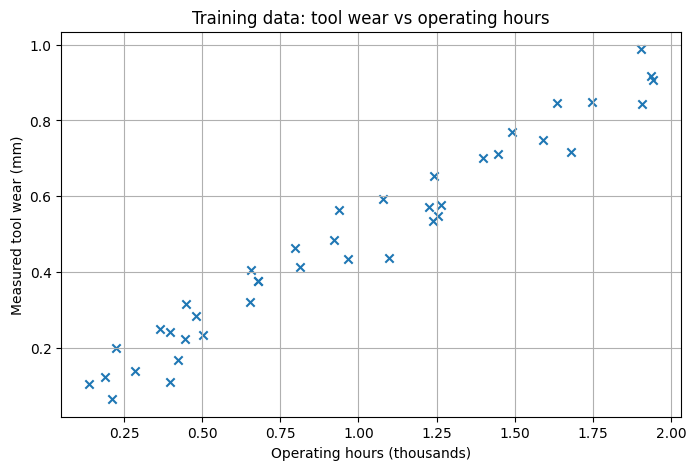

In [2]:
# --- Our running regression dataset: tool wear vs operating hours ---
# We simulate what a CMM / micrometer measurement log might look like:
# wear grows roughly linearly with hours, plus measurement noise.

m = 40                                              # m = number of training examples
hours_k = np.random.uniform(0.1, 2.0, m)            # operating hours in THOUSANDS (0.1k–2k hrs)
true_w, true_b = 0.45, 0.05                         # "ground truth" nature uses (unknown in real life)
wear_mm = true_w * hours_k + true_b + np.random.normal(0, 0.06, m)  # add sensor/measurement noise

x_train = hours_k          # convention: x_train, y_train — matches the course labs
y_train = wear_mm

# A quick look at the data as an engineer would receive it
df = pd.DataFrame({"operating_hours_k": x_train, "tool_wear_mm": y_train})
print(df.head())
print(f"\nm = {len(x_train)} training examples")

plt.scatter(x_train, y_train, c="tab:blue", marker="x")
plt.xlabel("Operating hours (thousands)")
plt.ylabel("Measured tool wear (mm)")
plt.title("Training data: tool wear vs operating hours")
plt.show()

---
## 2. Linear Regression with One Variable

**What:** fit a straight line to the data:

$$f_{w,b}(x) = w x + b$$

- $w$ = slope: mm of extra wear per 1,000 operating hours.
- $b$ = intercept: predicted wear at 0 hours (here: initial surface imperfection).

**Why start here:** it's the simplest model whose *training machinery* (cost function + gradient descent) is **identical in structure** to what trains neural networks. Learn the machinery on a model you can plot.

**Common pitfalls**
- Confusing the **model** ($f_{w,b}$, makes predictions) with the **cost** ($J$, scores how bad the predictions are). They're separate objects.
- Reading $w$ without units. Here $w \approx 0.45$ means *0.45 mm wear per 1,000 hrs* — always attach units when interpreting learned parameters; it makes them physically meaningful and catches unit-mismatch bugs early.

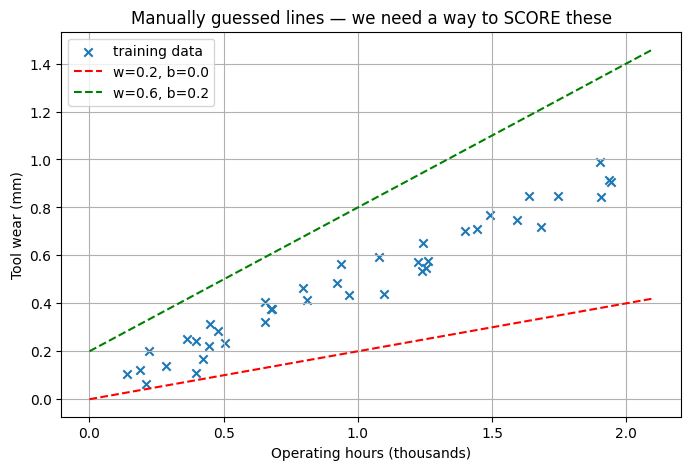

In [3]:
def predict(x, w, b):
    '''Linear model f_wb(x) = w*x + b. Works on scalars or NumPy arrays (broadcasting).'''
    return w * x + b

# 🔧 Reusable pattern: keep the model as its own tiny function.
# Every algorithm in this course = (model) + (cost) + (optimizer). Separating them
# means you can swap the model (linear -> logistic) without touching the optimizer.

# Two manual guesses to see what w and b do:
w_guess1, b_guess1 = 0.2, 0.0   # too shallow
w_guess2, b_guess2 = 0.6, 0.2   # too steep + offset

xs = np.linspace(0, 2.1, 50)                       # smooth x range for drawing lines
plt.scatter(x_train, y_train, c="tab:blue", marker="x", label="training data")
plt.plot(xs, predict(xs, w_guess1, b_guess1), "r--", label=f"w={w_guess1}, b={b_guess1}")
plt.plot(xs, predict(xs, w_guess2, b_guess2), "g--", label=f"w={w_guess2}, b={b_guess2}")
plt.xlabel("Operating hours (thousands)"); plt.ylabel("Tool wear (mm)")
plt.title("Manually guessed lines — we need a way to SCORE these")
plt.legend(); plt.show()

# Neither guess looks right. "Looks right" isn't measurable -> we need a cost function.

---
## 3. Cost Function (Squared Error)

**What:** a single number measuring how badly the line with parameters $(w,b)$ fits *all* $m$ examples:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

The inner term $f_{w,b}(x^{(i)}) - y^{(i)}$ is the **error** on example $i$ (predicted − actual).

**Why each piece is there**
- **Square** the error → (a) negatives don't cancel positives, (b) big misses are punished disproportionately, (c) the function becomes smooth and **convex** (one bowl, one minimum) for linear regression.
- **$\frac{1}{m}$** → averaging makes $J$ comparable across dataset sizes.
- **$\frac{1}{2}$** → pure convenience: it cancels the 2 that falls out when you differentiate the square. Changes $J$'s value, not where its minimum is.

**Mental model:** training = *find the $(w,b)$ at the bottom of the bowl.* $J$ defines the bowl; Section 4 gives us a way to walk down it.

**Common pitfalls**
- $J$ is a function of the **parameters** $(w,b)$, not of $x$. The bowl plot's axes are $w$ and $b$ — the data is baked in.
- Squared error is the right default for regression; it is the **wrong** cost for classification (Section 9 shows why).

J for guess 1 (w=0.2, b=0.0): 0.0525
J for guess 2 (w=0.6, b=0.2): 0.0496
J near truth  (w=0.45,b=0.05): 0.0014


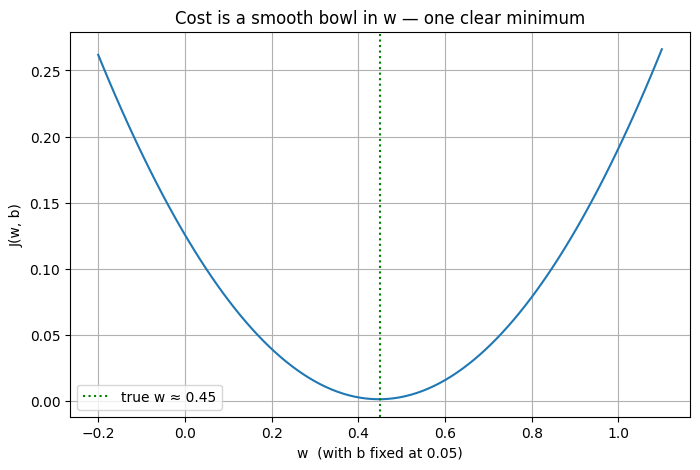

In [4]:
def compute_cost(x, y, w, b):
    '''
    Squared-error cost J(w,b) for 1-variable linear regression.
    Args:  x (ndarray (m,)), y (ndarray (m,)), w (scalar), b (scalar)
    Returns: cost (float)
    '''
    m = x.shape[0]
    err = predict(x, w, b) - y          # vector of per-example errors (prediction - actual)
    return np.sum(err ** 2) / (2 * m)   # square, sum, average, halve — the formula verbatim

# 🔧 Reusable pattern: cost functions always take (data, params) and return ONE float.
# That single number is what you log every training iteration to verify convergence.

print(f"J for guess 1 (w=0.2, b=0.0): {compute_cost(x_train, y_train, 0.2, 0.0):.4f}")
print(f"J for guess 2 (w=0.6, b=0.2): {compute_cost(x_train, y_train, 0.6, 0.2):.4f}")
print(f"J near truth  (w=0.45,b=0.05): {compute_cost(x_train, y_train, 0.45, 0.05):.4f}")

# Visualize the "bowl": sweep w with b fixed at its true value
w_range = np.linspace(-0.2, 1.1, 100)
costs = [compute_cost(x_train, y_train, w, 0.05) for w in w_range]
plt.plot(w_range, costs)
plt.axvline(0.45, color="green", ls=":", label="true w ≈ 0.45")
plt.xlabel("w  (with b fixed at 0.05)"); plt.ylabel("J(w, b)")
plt.title("Cost is a smooth bowl in w — one clear minimum")
plt.legend(); plt.show()

---
## 4. Gradient Descent

**What:** an iterative recipe for walking downhill on $J$. Repeat until convergence:

$$w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

For squared-error linear regression the derivatives work out to:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)x^{(i)}
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)$$

**Why it works:** the derivative is the local slope. Subtracting $\alpha \times$ slope moves you *against* the slope — downhill. Near the minimum the slope shrinks, so **steps shrink automatically even with a fixed $\alpha$** — which is why a decaying learning-rate schedule isn't needed for convex problems like these.

**The learning rate $\alpha$ (a hyperparameter — you choose it):**
- Too **small** → converges, but painfully slowly.
- Too **large** → overshoots the minimum, cost *increases* or oscillates → diverges.
- Practical recipe from the course: try $\alpha$ on a rough ×3 ladder (0.001, 0.003, 0.01, 0.03, 0.1, …) and watch the cost curve.

**Convergence check:** plot $J$ vs iteration. It must **decrease every iteration**. Flat curve ≈ converged (or declare convergence when the drop per iteration falls below some tiny $\epsilon$, e.g. $10^{-3}$).

**Common pitfalls**
- **Simultaneous update:** compute *both* gradients from the current $(w,b)$ *before* updating either. Updating $w$ first and then using the new $w$ to compute $b$'s gradient is a classic silent bug — the code often still converges, just to slightly wrong dynamics, which makes it hard to spot.
- This is **batch** gradient descent: every step uses *all* $m$ examples (later courses introduce stochastic/mini-batch variants).

Learned: w = 0.4542, b = 0.0412   (truth was w=0.45, b=0.05)
Final cost J = 0.00139


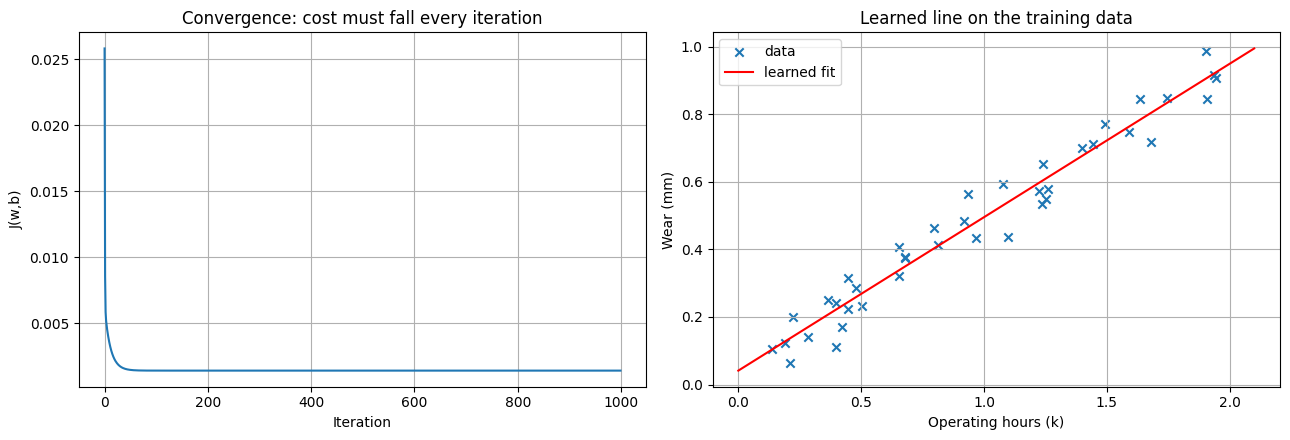

In [5]:
def compute_gradient(x, y, w, b):
    '''
    Gradients of squared-error cost for 1-variable linear regression.
    Returns: (dj_dw, dj_db) — both scalars.
    '''
    m = x.shape[0]
    err = predict(x, w, b) - y          # same error vector as the cost — reuse the idea
    dj_dw = np.sum(err * x) / m         # each error weighted by its x (from the chain rule)
    dj_db = np.sum(err) / m             # bias gradient = plain average error
    return dj_dw, dj_db


def gradient_descent(x, y, w_init, b_init, alpha, num_iters, cost_fn, gradient_fn):
    '''
    Generic batch gradient descent. Works for ANY model whose cost/gradient
    functions share this signature — we reuse it unchanged for logistic regression.
    Returns: final w, final b, and J_history (cost per iteration, for the convergence plot).
    '''
    w, b = w_init, b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = gradient_fn(x, y, w, b)   # BOTH gradients from current (w,b)...
        w = w - alpha * dj_dw                    # ...THEN update. This is the
        b = b - alpha * dj_db                    # "simultaneous update" done correctly.
        J_history.append(cost_fn(x, y, w, b))
    return w, b, J_history

# 🔧 Reusable pattern: gradient_descent() is deliberately model-agnostic — it only
# talks to the model through cost_fn/gradient_fn. Copy this into your project and
# you have a training loop that logs a full convergence history for free.

w_final, b_final, J_hist = gradient_descent(
    x_train, y_train, w_init=0.0, b_init=0.0,
    alpha=0.3, num_iters=1000,
    cost_fn=compute_cost, gradient_fn=compute_gradient
)
print(f"Learned: w = {w_final:.4f}, b = {b_final:.4f}   (truth was w=0.45, b=0.05)")
print(f"Final cost J = {J_hist[-1]:.5f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(J_hist)
ax1.set_xlabel("Iteration"); ax1.set_ylabel("J(w,b)")
ax1.set_title("Convergence: cost must fall every iteration")
ax2.scatter(x_train, y_train, c="tab:blue", marker="x", label="data")
ax2.plot(xs, predict(xs, w_final, b_final), "r-", label="learned fit")
ax2.set_xlabel("Operating hours (k)"); ax2.set_ylabel("Wear (mm)")
ax2.set_title("Learned line on the training data")
ax2.legend()
plt.tight_layout(); plt.show()

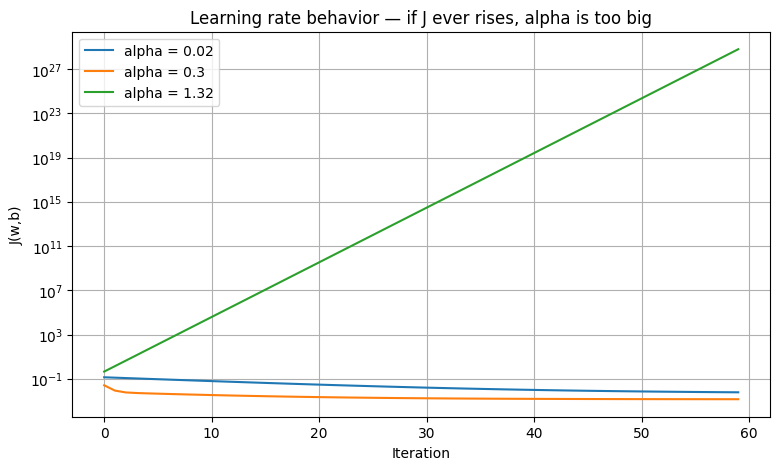

In [6]:
# --- Learning-rate experiment: see 'too small' vs 'good' vs 'too big' with your own eyes ---
plt.figure(figsize=(9, 5))
for alpha in [0.02, 0.3, 1.32]:                    # slow / good / on the edge of divergence
    _, _, Jh = gradient_descent(x_train, y_train, 0.0, 0.0, alpha, 60,
                                compute_cost, compute_gradient)
    plt.plot(Jh, label=f"alpha = {alpha}")
plt.xlabel("Iteration"); plt.ylabel("J(w,b)"); plt.yscale("log")   # log scale: huge range
plt.title("Learning rate behavior — if J ever rises, alpha is too big")
plt.legend(); plt.show()

# Takeaway: alpha=0.02 crawls, 0.3 converges cleanly, 1.32 oscillates/climbs.
# When you see a rising or zig-zag cost curve in a real project: cut alpha ~3x and retry.

In [7]:
# --- Production shortcut: scikit-learn does all of the above in 3 lines ---
X_2d = x_train.reshape(-1, 1)          # sklearn expects X as a 2-D array: (m, n_features)
lr = LinearRegression()                 # uses a closed-form/least-squares solver, not GD
lr.fit(X_2d, y_train)
print(f"sklearn:      w = {lr.coef_[0]:.4f}, b = {lr.intercept_:.4f}")
print(f"our scratch:  w = {w_final:.4f}, b = {b_final:.4f}")

# Same answer (tiny differences = GD stopping tolerance). In production you use sklearn;
# the from-scratch version is what lets you DEBUG when a model refuses to train.

sklearn:      w = 0.4542, b = 0.0412
our scratch:  w = 0.4542, b = 0.0412


---
## 5. Multiple Linear Regression + Vectorization

**What:** real machines have more than one wear driver. With $n$ features the model becomes

$$f_{\mathbf{w},b}(\mathbf{x}) = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

- $\mathbf{x}$ = feature **vector** for one example (e.g. [hours, load, temp, vibration]).
- $\mathbf{X}$ = the whole training set as an $(m \times n)$ **matrix** — row $i$ is example $x^{(i)}$, column $j$ is feature $j$.
- $\mathbf{w}$ = one weight per feature; $b$ stays a single scalar.

**Why vectorize (write it as dot products instead of loops)?**
1. **Speed** — NumPy dispatches `np.dot` to optimized, parallel C/BLAS code. On large data this is orders of magnitude faster than Python loops, and it's the same mental model GPUs use.
2. **Correctness & readability** — `X @ w + b` *is* the math. Fewer indices, fewer off-by-one bugs.

Gradient descent barely changes — there's now one update per weight, all with the same shape:

$$w_j := w_j - \alpha \frac{1}{m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)x_j^{(i)} \qquad b := b - \alpha \frac{1}{m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)$$

**Common pitfalls**
- **Shape errors** are 90% of bugs here. Discipline: `X` is `(m, n)`, `w` is `(n,)`, `y` is `(m,)`. Print `.shape` the moment anything misbehaves.
- Note the course also mentions the **normal equation** (closed-form solve, no iterations) — fine for small linear problems, but it doesn't generalize to logistic regression or neural nets, which is why the course invests in gradient descent.

In [8]:
# --- Multi-feature predictive-maintenance dataset ---
# Features per machine-check: operating hours (k), spindle load (kN),
# operating temp (deg C), vibration RMS (mm/s). Target: measured wear (mm).
m = 60
X_raw = np.column_stack([
    np.random.uniform(0.1, 2.0, m),    # x1: hours (thousands)      ~ 0.1–2
    np.random.uniform(2, 12, m),       # x2: spindle load (kN)      ~ 2–12
    np.random.uniform(35, 90, m),      # x3: temperature (deg C)    ~ 35–90
    np.random.uniform(0.5, 8.0, m),    # x4: vibration RMS (mm/s)   ~ 0.5–8
])
true_w_multi = np.array([0.40, 0.030, 0.004, 0.050])   # each feature's real contribution
y_multi = X_raw @ true_w_multi + 0.05 + np.random.normal(0, 0.05, m)

feature_names = ["hours_k", "load_kN", "temp_C", "vib_mm_s"]
print(pd.DataFrame(X_raw, columns=feature_names).describe().round(2).loc[["mean", "min", "max"]])
print(f"\nX shape: {X_raw.shape}  (m={X_raw.shape[0]} examples, n={X_raw.shape[1]} features)")

# --- Loop vs vectorized prediction: same numbers, very different code ---
w_demo, b_demo = true_w_multi, 0.05

def predict_loop(X, w, b):                 # the "obvious" way — don't do this
    m, n = X.shape
    preds = np.zeros(m)
    for i in range(m):
        for j in range(n):
            preds[i] += w[j] * X[i, j]
        preds[i] += b
    return preds

def predict_vec(X, w, b):                  # the vectorized way — DO this
    return X @ w + b                       # (m,n) @ (n,) -> (m,) : one matrix product

print("\nloop == vectorized:", np.allclose(predict_loop(X_raw, w_demo, b_demo),
                                           predict_vec(X_raw, w_demo, b_demo)))

import time
X_big = np.random.rand(200_000, 4); w_big = np.random.rand(4)   # bigger data to time it
t0 = time.perf_counter(); predict_loop(X_big, w_big, 0.0); t_loop = time.perf_counter() - t0
t0 = time.perf_counter(); predict_vec(X_big, w_big, 0.0);  t_vec  = time.perf_counter() - t0
print(f"200k rows -> loop: {t_loop*1000:.0f} ms | vectorized: {t_vec*1000:.2f} ms "
      f"(~{t_loop/t_vec:.0f}x faster)")

      hours_k  load_kN  temp_C  vib_mm_s
mean     0.99     6.92   66.68      4.01
min      0.11     2.05   35.85      0.61
max      1.95    11.86   89.45      7.82

X shape: (60, 4)  (m=60 examples, n=4 features)

loop == vectorized: True


200k rows -> loop: 428 ms | vectorized: 2.65 ms (~162x faster)


In [9]:
def compute_cost_multi(X, y, w, b):
    '''Squared-error cost, vectorized for X of shape (m, n).'''
    m = X.shape[0]
    err = X @ w + b - y                    # (m,) vector of errors, one matrix product
    return np.sum(err ** 2) / (2 * m)

def compute_gradient_multi(X, y, w, b):
    '''Vectorized gradients: dj_dw is (n,), dj_db is scalar.'''
    m = X.shape[0]
    err = X @ w + b - y                    # (m,)
    dj_dw = X.T @ err / m                  # (n,m)@(m,) -> (n,): sums err*x_j per feature j
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters, cost_fn, gradient_fn):
    '''Same training loop as before, but w is now a vector. Copies arrays to stay pure.'''
    w = w_init.copy().astype(float)        # .copy() so we never mutate the caller's array
    b = float(b_init)
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = gradient_fn(X, y, w, b)
        w = w - alpha * dj_dw              # one vectorized line updates ALL n weights
        b = b - alpha * dj_db
        J_history.append(cost_fn(X, y, w, b))
    return w, b, J_history

# 🔧 Reusable pattern: this trio (vectorized cost / gradient / loop) is the core of a
# from-scratch linear model. X.T @ err / m is THE line to remember — it computes every
# weight's gradient in one shot.

# Try training on the RAW features:
w0 = np.zeros(X_raw.shape[1])
w_raw, b_raw, J_raw = gradient_descent_multi(X_raw, y_multi, w0, 0.0, alpha=3e-4,
                                             num_iters=1000,
                                             cost_fn=compute_cost_multi,
                                             gradient_fn=compute_gradient_multi)
print(f"After 1000 iters on RAW features: J = {J_raw[-1]:.4f}")
print("Learned w:", np.round(w_raw, 4), " b:", round(b_raw, 4))
print("True    w:", true_w_multi, " b: 0.05")
# Notice: alpha had to be TINY (3e-4) or it diverges, and it's still far from truth.
# Why? temp_C spans 35–90 while hours_k spans 0.1–2 -> wildly different scales.
# That's the cue for the next section.

After 1000 iters on RAW features: J = 0.0251
Learned w: [0.0447 0.0467 0.0079 0.0495]  b: 0.0087
True    w: [0.4   0.03  0.004 0.05 ]  b: 0.05


---
## 6. Feature Scaling & Choosing the Learning Rate

**What:** rescale every feature to a comparable range before gradient descent. The course's main tool is **z-score normalization**:

$$x_j^{scaled} = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j, \sigma_j$ are the mean and standard deviation of feature $j$ **computed on the training set**. (Alternatives: min–max scaling $\frac{x - min}{max - min}$, mean normalization.)

**Why it matters for gradient descent:** with unscaled features, the cost bowl is a long thin valley — steep along the large-scale feature (temp: 35–90), flat along the small one (hours: 0.1–2). GD zig-zags across the steep wall and inches along the valley floor, forcing a tiny $\alpha$. Scaling makes the bowl round → GD heads straight for the minimum and tolerates a much larger $\alpha$. **This is why the raw-feature run above needed $\alpha = 0.0003$ and still hadn't converged.**

**Common pitfalls (these bite in real projects)**
1. Compute $\mu, \sigma$ on **training data only**, then apply those *same* numbers to validation/test/production data. Recomputing on test data is a form of data leakage.
2. **Save $\mu, \sigma$ with the model.** A deployed model fed unscaled sensor readings outputs garbage silently — a classic MLOps failure mode.
3. Learned weights are now in *scaled* units — to interpret "wear per 1,000 hours" physically you must convert back ($w_{raw,j} = w_{scaled,j}/\sigma_j$).

Feature ranges BEFORE: [ 1.83  9.81 53.6   7.21]
Feature ranges AFTER:  [3.3  3.34 3.41 3.5 ]


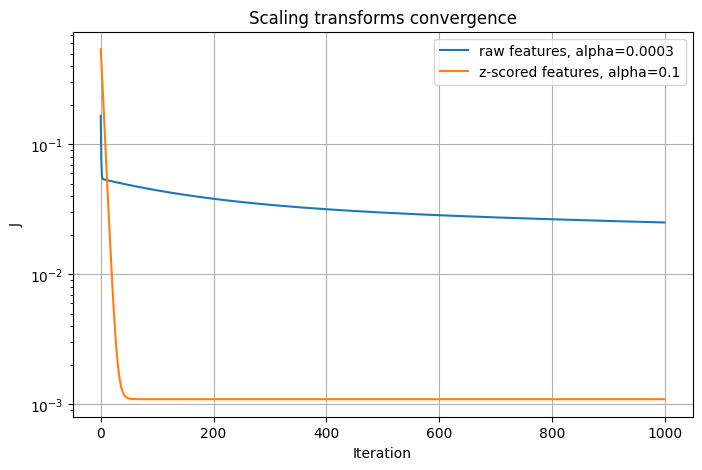

Scaled run: J = 0.00110 after 1000 iters (raw run was 0.0251)
Recovered physical w: [0.4017 0.0305 0.0037 0.0481]  vs true: [0.4   0.03  0.004 0.05 ]

sklearn matches our scratch scaler: True


In [10]:
def zscore_normalize(X):
    '''
    Z-score normalize each column of X.
    Returns: X_norm, mu, sigma  — KEEP mu and sigma; production data must be
    transformed with these exact training-set statistics.
    '''
    mu = np.mean(X, axis=0)                # per-column mean, shape (n,)
    sigma = np.std(X, axis=0)              # per-column std,  shape (n,)
    return (X - mu) / sigma, mu, sigma     # broadcasting: every row shifted & scaled

# 🔧 Reusable pattern: any scaler you write must RETURN its fitted statistics.
# Project rule: fit on train -> transform train/val/test/production with the same mu, sigma.

X_norm, mu, sigma = zscore_normalize(X_raw)
print("Feature ranges BEFORE:", np.round(X_raw.max(0) - X_raw.min(0), 2))
print("Feature ranges AFTER: ", np.round(X_norm.max(0) - X_norm.min(0), 2))

# Retrain on scaled features — note alpha is now 0.1 (330x larger) and it nails it fast:
w_s, b_s, J_s = gradient_descent_multi(X_norm, y_multi, np.zeros(4), 0.0, alpha=0.1,
                                       num_iters=1000, cost_fn=compute_cost_multi,
                                       gradient_fn=compute_gradient_multi)
plt.plot(J_raw, label="raw features, alpha=0.0003")
plt.plot(J_s,   label="z-scored features, alpha=0.1")
plt.xlabel("Iteration"); plt.ylabel("J"); plt.yscale("log")
plt.title("Scaling transforms convergence"); plt.legend(); plt.show()
print(f"Scaled run: J = {J_s[-1]:.5f} after 1000 iters (raw run was {J_raw[-1]:.4f})")

# Convert weights back to physical units to sanity-check against ground truth:
w_physical = w_s / sigma
print("Recovered physical w:", np.round(w_physical, 4), " vs true:", true_w_multi)

# --- sklearn equivalent ---
scaler = StandardScaler().fit(X_raw)       # .fit LEARNS mu/sigma; .transform APPLIES them
X_sk = scaler.transform(X_raw)
print("\nsklearn matches our scratch scaler:", np.allclose(X_sk, X_norm))

---
## 7. Feature Engineering & Polynomial Regression

**What:** creating *new* features from existing ones, using intuition or domain knowledge, so a **linear** model can capture **nonlinear** reality. The course example: from lot `width` and `depth`, engineer `area = width × depth`. Polynomial regression is the systematic version — add powers of a feature:

$$f_{\mathbf{w},b}(x) = w_1 x + w_2 x^2 + w_3 x^3 + b$$

**The key insight:** this is *still linear regression* — linear **in the parameters** $\mathbf{w}$. You've just changed what the columns of $X$ contain. Same cost, same gradient descent, same code.

**Why this matters in industrial ML:** feature engineering is where domain knowledge beats generic ML skill. Mechanical wear often follows power laws (e.g. Archard's equation), vibration and load can interact multiplicatively, temperature effects can be threshold-like. Encoding physics as features — `load × vibration`, `hours^1.5`, a temperature-exceedance indicator — is a genuine differentiator in applied machine learning.

**Common pitfalls**
- Polynomial features have **wildly different scales** ($x \in [0,2] \Rightarrow x^3 \in [0,8]$, but $x \in [0,90] \Rightarrow x^3 \in [0, 729{,}000]$). **Always rescale after expanding.**
- Higher degree = more flexibility = more overfitting risk (Section 11 deals with this).

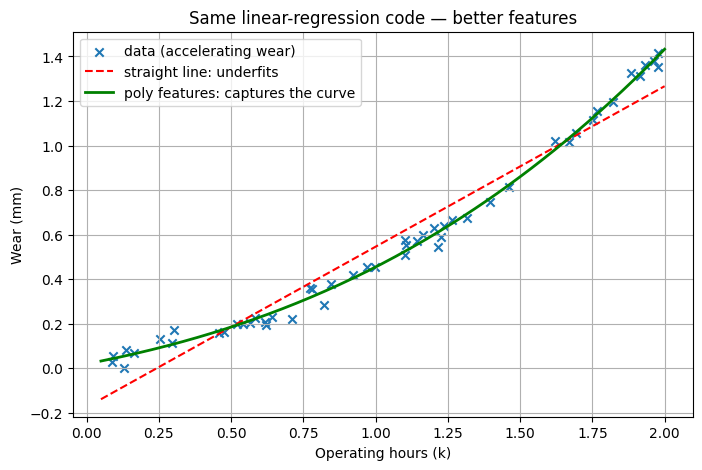

sklearn pipeline R^2 on training data: 0.9951


In [11]:
# --- Nonlinear reality: wear that accelerates with hours (power-law, like real abrasive wear) ---
m_p = 50
hours_p = np.sort(np.random.uniform(0.05, 2.0, m_p))
wear_p = 0.30 * hours_p**2 + 0.10 * hours_p + 0.05 + np.random.normal(0, 0.03, m_p)

# Attempt 1: plain linear fit (underfits — systematically wrong at both ends)
X_lin = hours_p.reshape(-1, 1)
w_lin, b_lin, _ = gradient_descent_multi(X_lin, wear_p, np.zeros(1), 0.0, 0.3, 2000,
                                         compute_cost_multi, compute_gradient_multi)

# Attempt 2: ENGINEER features x, x^2, x^3 -> then scale -> then the SAME linear machinery
X_poly = np.column_stack([hours_p, hours_p**2, hours_p**3])   # feature engineering step
X_poly_n, mu_p, sig_p = zscore_normalize(X_poly)              # rescale AFTER expanding
w_p, b_p, _ = gradient_descent_multi(X_poly_n, wear_p, np.zeros(3), 0.0, 0.1, 5000,
                                     compute_cost_multi, compute_gradient_multi)

grid = np.linspace(0.05, 2.0, 200)                            # smooth grid for plotting fits
grid_poly_n = (np.column_stack([grid, grid**2, grid**3]) - mu_p) / sig_p  # same transform!
plt.scatter(hours_p, wear_p, marker="x", label="data (accelerating wear)")
plt.plot(grid, grid * w_lin[0] + b_lin, "r--", label="straight line: underfits")
plt.plot(grid, grid_poly_n @ w_p + b_p, "g-", lw=2, label="poly features: captures the curve")
plt.xlabel("Operating hours (k)"); plt.ylabel("Wear (mm)")
plt.title("Same linear-regression code — better features"); plt.legend(); plt.show()

# 🔧 Reusable pattern: transform plot-grid/production inputs with the SAME pipeline
# (expand -> subtract mu -> divide sigma) as training data. Mismatched pipelines are
# the #1 cause of "model works in notebook, fails in production".

# --- sklearn equivalent: pipeline = expansion + scaling + model, welded together ---
poly_model = make_pipeline(PolynomialFeatures(degree=3, include_bias=False),
                           StandardScaler(),
                           LinearRegression())
poly_model.fit(hours_p.reshape(-1, 1), wear_p)     # pipeline handles transforms internally
print("sklearn pipeline R^2 on training data:", round(poly_model.score(X_lin, wear_p), 4))
# A Pipeline object bundles the preprocessing WITH the model, so you can't forget
# to apply it at prediction time — use pipelines in every real project.

---
## 8. Logistic Regression, the Sigmoid & Decision Boundaries

**What:** the course's algorithm for **binary classification** ($y \in \{0, 1\}$). Despite the name, it's a *classification* method.

**Why not just use linear regression on 0/1 labels?** Two reasons the course demonstrates:
1. Its output isn't bounded to $[0,1]$, so it can't be read as a probability.
2. A single far-out example (e.g. one machine run to extreme hours) drags the line and **shifts the decision threshold** — misclassifying points it previously got right. Classification needs a model that saturates.

**The fix:** squash the linear score through the **sigmoid**:

$$z = \mathbf{w} \cdot \mathbf{x} + b \qquad g(z) = \frac{1}{1 + e^{-z}} \qquad f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w} \cdot \mathbf{x} + b)$$

Sigmoid maps any real $z$ to $(0,1)$; interpret the output as $P(y{=}1 \mid \mathbf{x})$ — e.g. "0.83 → 83% chance this part fails QC."

**Decision boundary:** predict 1 when $f \geq 0.5$, which happens exactly when $z \geq 0$. So the boundary is the set where

$$\mathbf{w} \cdot \mathbf{x} + b = 0$$

— a straight line (plane) in feature space. Feed in polynomial features (Section 7) and $z=0$ can trace circles, ellipses, arbitrary curves: **nonlinear boundaries from the same machinery**.

**Common pitfalls**
- The 0.5 threshold is a *choice*, not a law. In predictive maintenance, a missed failure usually costs far more than a false alarm → you'd often lower the threshold (flag at $P \geq 0.3$).
- The model outputs a **probability**; the class label only appears after you apply a threshold. Keep those two steps separate in code.

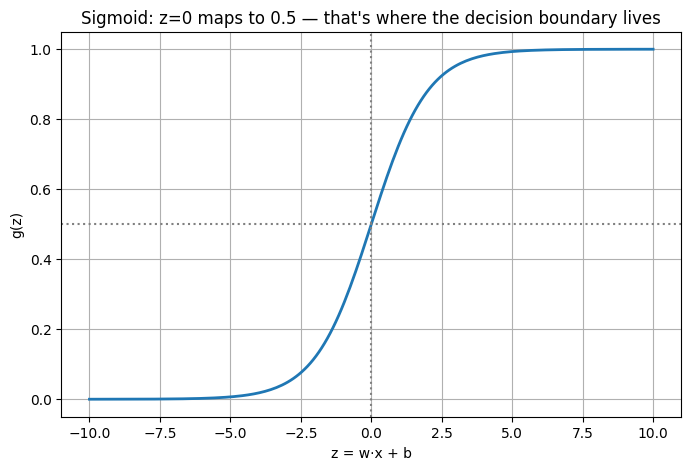

55 fails / 45 passes


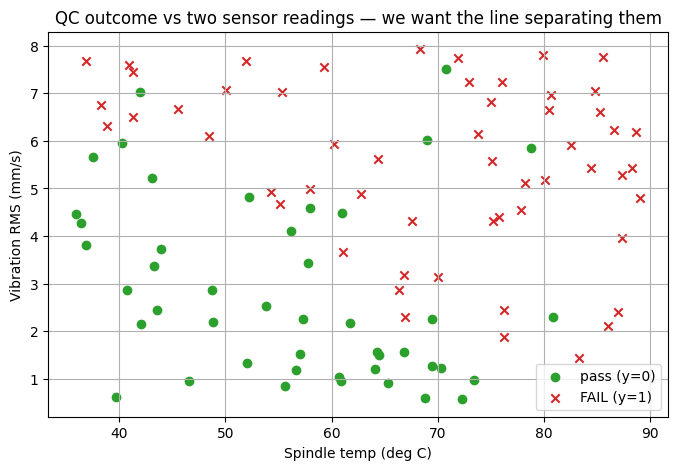

In [12]:
def sigmoid(z):
    '''Numerically maps any real z (scalar or array) to (0, 1).'''
    return 1 / (1 + np.exp(-z))

# 🔧 Reusable pattern: sigmoid is everywhere — logistic regression, neural-net output
# layers, gating in LSTMs. Three properties to remember: g(0)=0.5, g(-z)=1-g(z),
# and it saturates (gradient -> 0) for |z| > ~5.

z_vals = np.linspace(-10, 10, 200)
plt.plot(z_vals, sigmoid(z_vals), lw=2)
plt.axhline(0.5, color="gray", ls=":"); plt.axvline(0, color="gray", ls=":")
plt.xlabel("z = w·x + b"); plt.ylabel("g(z)")
plt.title("Sigmoid: z=0 maps to 0.5 — that's where the decision boundary lives")
plt.show()

# --- Classification dataset: part pass/fail from two sensor readings ---
# Physically: parts machined at high temperature AND high vibration tend to fail QC.
m_c = 100
temp_c = np.random.uniform(35, 90, m_c)          # spindle temp (deg C)
vib_c = np.random.uniform(0.5, 8.0, m_c)         # vibration RMS (mm/s)
# Failure probability rises with a weighted combo of both; sample actual labels from it:
z_true = 0.12 * (temp_c - 62) + 0.9 * (vib_c - 4.2)
y_c = (np.random.rand(m_c) < sigmoid(z_true)).astype(int)   # 1 = FAIL, 0 = PASS

X_c = np.column_stack([temp_c, vib_c])
X_cn, mu_c, sigma_c = zscore_normalize(X_c)      # scale now — logistic GD needs it too
print(f"{y_c.sum()} fails / {m_c - y_c.sum()} passes")

plt.scatter(temp_c[y_c==0], vib_c[y_c==0], marker="o", c="tab:green", label="pass (y=0)")
plt.scatter(temp_c[y_c==1], vib_c[y_c==1], marker="x", c="tab:red", label="FAIL (y=1)")
plt.xlabel("Spindle temp (deg C)"); plt.ylabel("Vibration RMS (mm/s)")
plt.title("QC outcome vs two sensor readings — we want the line separating them")
plt.legend(); plt.show()

---
## 9. Cost Function for Logistic Regression (Log Loss)

**What & why:** plugging the sigmoid into squared error produces a **non-convex** cost — a lumpy landscape full of local minima where gradient descent gets stuck. So classification uses the **logistic loss** on each example:

$$L(f, y) = \begin{cases} -\log(f) & \text{if } y = 1 \\ -\log(1 - f) & \text{if } y = 0 \end{cases}$$

**Intuition:** if the true label is 1 and the model says $f = 0.99$, loss $\approx 0.01$ — tiny. If it confidently says $f = 0.01$, loss $= -\log(0.01) \approx 4.6$, and $\to \infty$ as $f \to 0$. **Confident-and-wrong is punished without bound** — exactly the incentive you want for a probability estimator.

Both cases compress into one line (when $y{=}1$ the second term vanishes; when $y{=}0$ the first does), giving the full cost:

$$J(\mathbf{w},b) = -\frac{1}{m}\sum_{i=1}^{m}\left[ y^{(i)}\log f^{(i)} + (1-y^{(i)})\log(1-f^{(i)}) \right]$$

This cost **is convex** for logistic regression → one global minimum → gradient descent is safe again. (It's derived from maximum likelihood — the statistics behind *why* this specific formula; the course flags this in passing.)

**Common pitfalls**
- `np.log(0)` = `-inf`. If the sigmoid saturates to exactly 0.0 or 1.0 in float arithmetic, the cost becomes `nan`. Production trick: clip predictions to `[eps, 1-eps]` before logging.
- Note there's **no $\frac{1}{2}$** here (nothing to cancel) — don't blindly copy the squared-error prefactor.

In [13]:
def compute_cost_logistic(X, y, w, b):
    '''
    Log-loss cost for logistic regression, vectorized.
    Clips predictions away from exact 0/1 so np.log never sees 0 -> no NaNs.
    '''
    m = X.shape[0]
    f = sigmoid(X @ w + b)                          # predicted probabilities, shape (m,)
    eps = 1e-15
    f = np.clip(f, eps, 1 - eps)                    # numerical safety: keep log() finite
    return -np.sum(y * np.log(f) + (1 - y) * np.log(1 - f)) / m

# 🔧 Reusable pattern: the clip-before-log guard belongs in EVERY log-loss you write.
# Silent NaNs from log(0) are one of the most common "my training exploded" bugs.

# Feel the asymmetry of log loss on single predictions:
for f_pred, y_true in [(0.99, 1), (0.60, 1), (0.01, 1)]:
    loss = -np.log(f_pred) if y_true == 1 else -np.log(1 - f_pred)
    print(f"true y=1, predicted P={f_pred:.2f} -> loss {loss:6.3f}")
print("\nConfidently wrong (P=0.01 when y=1) costs ~460x more than confidently right.")

print(f"\nCost at w=[0,0], b=0 (i.e. predicting 0.5 for everything): "
      f"{compute_cost_logistic(X_cn, y_c, np.zeros(2), 0.0):.4f}")
print("(-log(0.5) = 0.693 — a useful baseline: any trained model must beat 0.693.)")

true y=1, predicted P=0.99 -> loss  0.010


true y=1, predicted P=0.60 -> loss  0.511
true y=1, predicted P=0.01 -> loss  4.605

Confidently wrong (P=0.01 when y=1) costs ~460x more than confidently right.

Cost at w=[0,0], b=0 (i.e. predicting 0.5 for everything): 0.6931
(-log(0.5) = 0.693 — a useful baseline: any trained model must beat 0.693.)


---
## 10. Gradient Descent for Logistic Regression

**What:** the surprise the course builds up to — the gradient formulas are **identical in form** to linear regression's:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(f^{(i)} - y^{(i)}\right)x_j^{(i)} \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(f^{(i)} - y^{(i)}\right)$$

The **only** difference is hiding inside $f$: linear uses $f = \mathbf{w}\cdot\mathbf{x} + b$, logistic uses $f = g(\mathbf{w}\cdot\mathbf{x}+b)$. (This isn't coincidence — the log-loss derivative and the sigmoid derivative cancel perfectly. Same "error × feature" pattern shows up again in neural-net backprop.)

**Why this is great for code:** our `gradient_descent_multi` loop doesn't change at all. We swap in a logistic gradient function and everything — learning-rate advice, convergence plots, feature-scaling requirement, simultaneous update — carries over verbatim.

**Common pitfalls**
- Logistic regression trained by GD **still needs scaled features** for the same bowl-shape reasons.
- Track **log-loss** for convergence, but report **accuracy** (or better: precision/recall for imbalanced failure data) to stakeholders — they answer different questions.

Final log-loss: 0.3540  (baseline was 0.693)
Training accuracy: 87.0%


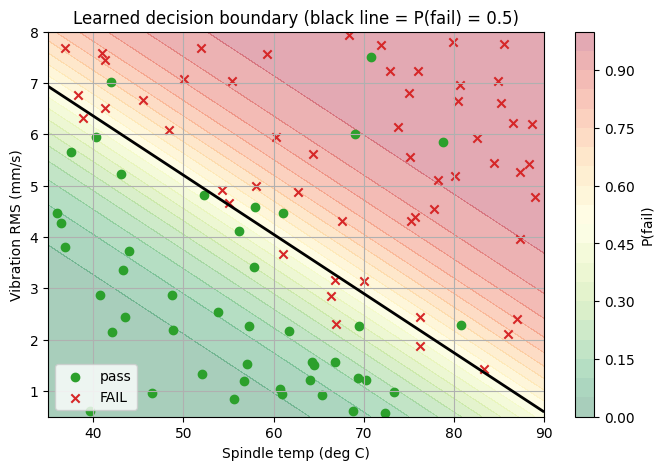

In [14]:
def compute_gradient_logistic(X, y, w, b):
    '''Gradients of log loss. Structurally identical to the linear version —
    only the prediction line differs (sigmoid wrapper).'''
    m = X.shape[0]
    err = sigmoid(X @ w + b) - y            # <- the ONLY changed line vs linear regression
    dj_dw = X.T @ err / m
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

# Reuse the SAME training loop from Section 5 — model-agnostic design paying off:
w_log, b_log, J_log = gradient_descent_multi(
    X_cn, y_c, np.zeros(2), 0.0, alpha=0.5, num_iters=3000,
    cost_fn=compute_cost_logistic, gradient_fn=compute_gradient_logistic)

print(f"Final log-loss: {J_log[-1]:.4f}  (baseline was 0.693)")
preds = (sigmoid(X_cn @ w_log + b_log) >= 0.5).astype(int)   # threshold AFTER probability
print(f"Training accuracy: {(preds == y_c).mean():.1%}")

# --- Plot the learned decision boundary in ORIGINAL sensor units ---
# Build a grid over the feature space, scale it with the training mu/sigma, get P(fail):
tt, vv = np.meshgrid(np.linspace(35, 90, 200), np.linspace(0.5, 8, 200))
grid_n = (np.column_stack([tt.ravel(), vv.ravel()]) - mu_c) / sigma_c    # same transform!
P = sigmoid(grid_n @ w_log + b_log).reshape(tt.shape)

plt.contourf(tt, vv, P, levels=20, cmap="RdYlGn_r", alpha=0.35)  # probability field
plt.colorbar(label="P(fail)")
plt.contour(tt, vv, P, levels=[0.5], colors="k", linewidths=2)   # the boundary: P = 0.5
plt.scatter(temp_c[y_c==0], vib_c[y_c==0], marker="o", c="tab:green", label="pass")
plt.scatter(temp_c[y_c==1], vib_c[y_c==1], marker="x", c="tab:red", label="FAIL")
plt.xlabel("Spindle temp (deg C)"); plt.ylabel("Vibration RMS (mm/s)")
plt.title("Learned decision boundary (black line = P(fail) = 0.5)")
plt.legend(); plt.show()

# 🔧 Reusable pattern: this meshgrid -> transform -> predict -> contour recipe draws a
# decision boundary for ANY 2-feature classifier. Keep it for portfolio visuals.

In [15]:
# --- Production shortcut: scikit-learn ---
clf = LogisticRegression()          # default solver handles optimization + regularization
clf.fit(X_cn, y_c)                  # fit on the SAME scaled features for comparison
print("sklearn accuracy:", f"{clf.score(X_cn, y_c):.1%}")
print("sklearn w:", np.round(clf.coef_[0], 3), " b:", round(clf.intercept_[0], 3))
print("scratch w:", np.round(w_log, 3), " b:", round(b_log, 3))
print("\n(Small differences are expected: sklearn applies L2 regularization by")
print(" default — C=1.0 — which shrinks weights slightly. Section 11 explains this.)")
print("\nProbabilities via predict_proba (column 1 = P(y=1)):")
print(np.round(clf.predict_proba(X_cn[:3]), 3))

sklearn accuracy: 86.0%
sklearn w: [1.354 1.751]  b: 0.48
scratch w: [1.707 2.143]  b: 0.603

(Small differences are expected: sklearn applies L2 regularization by
 default — C=1.0 — which shrinks weights slightly. Section 11 explains this.)

Probabilities via predict_proba (column 1 = P(y=1)):
[[0.446 0.554]
 [0.56  0.44 ]
 [0.57  0.43 ]]


---
## 11. Overfitting, Underfitting & L2 Regularization

**The problem, in course vocabulary:**

| Fit | Also called | Symptom | Cause |
|---|---|---|---|
| **Underfit** | high **bias** | wrong even on training data | model too simple / features too weak |
| **Just right** | — | fits training data, *generalizes* to new data | — |
| **Overfit** | high **variance** | near-perfect on training data, bad on new data | model too flexible for the data available |

"Bias" here = a strong preconception (e.g. "wear is linear") the data can't overcome. "Variance" = the fitted model would change wildly if you re-collected the training set — it memorized noise.

**Three remedies the course gives (in order of preference):**
1. **Collect more data** — often the best fix, not always possible.
2. **Use fewer features** — feature selection; risks discarding useful signal.
3. **Regularization** — keep all features but *shrink* the weights. Gentler than deleting.

**L2 regularization:** add a penalty on weight size to the cost (either cost — squared error or log loss):

$$J_{reg}(\mathbf{w},b) = J(\mathbf{w},b) + \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2$$

Gradient descent now fights two forces: fit the data (first term) vs keep weights small (second). $\lambda$ sets the balance:
- $\lambda = 0$ → no penalty → overfitting risk unchanged.
- $\lambda$ huge → weights crushed toward 0 → model flatlines at $\approx b$ → underfits.

The weight gradient gains one term (only the derivative changes; the update rule is untouched):

$$\frac{\partial J_{reg}}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(f^{(i)} - y^{(i)}\right)x_j^{(i)} + \frac{\lambda}{m} w_j$$

**Why $b$ is not regularized:** $b$ just shifts the whole prediction up/down — it doesn't create wiggle, so penalizing it doesn't reduce overfitting (it can even hurt by biasing predictions off-center). Course convention: penalize $w_j$ only.

**Common pitfalls**
- $\lambda$ is a hyperparameter — in a real project you choose it with a validation set / cross-validation (Course 2 territory), never by eyeballing training cost.
- sklearn's `LogisticRegression` uses `C = 1/λ` (inverted!): **larger C = LESS regularization.** Perennial source of confusion.
- Interview staple — be ready to explain aloud: (1) *why* shrinking weights reduces overfitting (smaller weights → smaller output swings per unit input → smoother functions), (2) why $b$ is excluded, and (3) what happens at both extremes of $\lambda$.

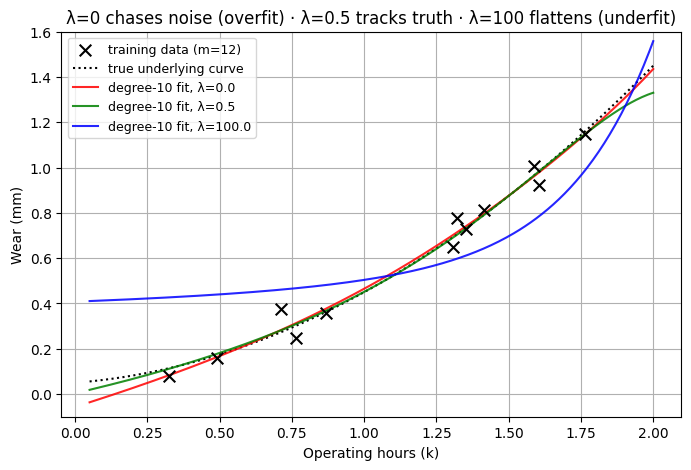

In [16]:
# --- Overfitting demo: high-degree polynomial on a SMALL wear dataset ---
m_small = 12                                        # few samples: overfitting's favorite food
h_small = np.sort(np.random.uniform(0.05, 2.0, m_small))
w_small = 0.30 * h_small**2 + 0.10 * h_small + 0.05 + np.random.normal(0, 0.04, m_small)

degree = 10                                         # way more flexibility than the data merits
X_deg = np.column_stack([h_small**d for d in range(1, degree + 1)])
X_degn, mu_d, sig_d = zscore_normalize(X_deg)       # must scale — x^10 spans ~0 to 1024

def compute_cost_linear_reg(X, y, w, b, lambda_):
    '''Squared-error cost + L2 penalty. Note: b is NOT in the penalty sum.'''
    m = X.shape[0]
    err = X @ w + b - y
    return np.sum(err**2) / (2*m) + (lambda_ / (2*m)) * np.sum(w**2)

def compute_gradient_linear_reg(X, y, w, b, lambda_):
    '''Linear-regression gradients + the (lambda/m)*w_j shrink term on dj_dw only.'''
    m = X.shape[0]
    err = X @ w + b - y
    dj_dw = X.T @ err / m + (lambda_ / m) * w       # <- the one new term
    dj_db = np.sum(err) / m                         # b's gradient: unchanged (not penalized)
    return dj_dw, dj_db

# 🔧 Reusable pattern: regularization = ONE extra term in cost and ONE in the w-gradient.
# The same two lines regularize logistic regression (swap in sigmoid + log loss).

def train_reg(lambda_):
    '''Wrap our generic loop so cost/gradient carry the chosen lambda.'''
    return gradient_descent_multi(
        X_degn, w_small, np.zeros(degree), 0.0, alpha=0.1, num_iters=10000,
        cost_fn=lambda X, y, w, b: compute_cost_linear_reg(X, y, w, b, lambda_),
        gradient_fn=lambda X, y, w, b: compute_gradient_linear_reg(X, y, w, b, lambda_))

grid_h = np.linspace(0.05, 2.0, 300)
grid_deg = (np.column_stack([grid_h**d for d in range(1, degree + 1)]) - mu_d) / sig_d

plt.scatter(h_small, w_small, s=70, marker="x", c="k", zorder=5, label="training data (m=12)")
plt.plot(grid_h, 0.30*grid_h**2 + 0.10*grid_h + 0.05, "k:", label="true underlying curve")
for lam, style in [(0.0, "r-"), (0.5, "g-"), (100.0, "b-")]:
    w_r, b_r, _ = train_reg(lam)
    plt.plot(grid_h, grid_deg @ w_r + b_r, style, alpha=0.85, label=f"degree-10 fit, λ={lam}")
plt.ylim(-0.1, 1.6)
plt.xlabel("Operating hours (k)"); plt.ylabel("Wear (mm)")
plt.title("λ=0 chases noise (overfit) · λ=0.5 tracks truth · λ=100 flattens (underfit)")
plt.legend(fontsize=9); plt.show()

In [17]:
# --- Weight shrinkage: what lambda actually does to the parameters ---
for lam in [0.0, 0.5, 100.0]:
    w_r, b_r, _ = train_reg(lam)
    print(f"λ={lam:>6}: |w| max = {np.abs(w_r).max():8.3f},  sum(w^2) = {np.sum(w_r**2):9.3f}")
print("\nBigger λ -> smaller weights -> smoother curve. That IS regularization.")

# --- sklearn equivalents ---
# Regression: Ridge(alpha=...) — sklearn calls the L2 strength 'alpha' (it plays the
# role of λ, NOT the learning rate!). Caveat: sklearn's penalty term isn't divided
# by 2m like the course's, so alpha and λ aren't numerically interchangeable — treat
# each as the knob to tune, not an exact conversion.
# Classification: LogisticRegression(C=...) where C is INVERSE regularization strength
# (bigger C = weaker penalty), conceptually C ≈ 1/λ with the same scaling caveat.
ridge = make_pipeline(PolynomialFeatures(degree=10, include_bias=False),
                      StandardScaler(), Ridge(alpha=0.5))
ridge.fit(h_small.reshape(-1, 1), w_small)
print(f"\nRidge(alpha=0.5) pipeline R^2 (train): {ridge.score(h_small.reshape(-1,1), w_small):.3f}")

weak_reg   = LogisticRegression(C=100.0).fit(X_cn, y_c)   # C large  -> λ small -> weak reg
strong_reg = LogisticRegression(C=0.01).fit(X_cn, y_c)    # C small  -> λ large -> strong reg
print("LogisticRegression |w| with weak reg (C=100):", np.round(np.abs(weak_reg.coef_[0]), 3))
print("LogisticRegression |w| with strong reg (C=0.01):", np.round(np.abs(strong_reg.coef_[0]), 3))
print("Remember: in sklearn classification, LARGER C = LESS regularization.")

λ=   0.0: |w| max =    0.182,  sum(w^2) =     0.044


λ=   0.5: |w| max =    0.135,  sum(w^2) =     0.033


λ= 100.0: |w| max =    0.022,  sum(w^2) =     0.003

Bigger λ -> smaller weights -> smoother curve. That IS regularization.

Ridge(alpha=0.5) pipeline R^2 (train): 0.980
LogisticRegression |w| with weak reg (C=100): [1.701 2.137]
LogisticRegression |w| with strong reg (C=0.01): [0.167 0.235]
Remember: in sklearn classification, LARGER C = LESS regularization.


---
## 📋 One-Page Cheat Sheet — Course 1

### Models
| Model | Prediction | Output |
|---|---|---|
| Linear regression | $f = \mathbf{w}\cdot\mathbf{x} + b$ | any real number |
| Polynomial regression | linear regression on engineered features $x, x^2, \dots$ | any real number |
| Logistic regression | $f = g(\mathbf{w}\cdot\mathbf{x}+b)$, $\;g(z)=\frac{1}{1+e^{-z}}$ | probability $\in (0,1)$ |

### Costs
| Cost | Formula | Use for |
|---|---|---|
| Squared error | $J = \frac{1}{2m}\sum (f^{(i)} - y^{(i)})^2$ | regression |
| Log loss | $J = -\frac{1}{m}\sum \big[y^{(i)}\log f^{(i)} + (1{-}y^{(i)})\log(1{-}f^{(i)})\big]$ | classification |
| L2 penalty (add to either) | $+\ \frac{\lambda}{2m}\sum_j w_j^2$ | fight overfitting |

### Gradient descent (identical form for both models)
$$w_j := w_j - \alpha\Big[\tfrac{1}{m}\textstyle\sum(f^{(i)}-y^{(i)})x_j^{(i)} + \tfrac{\lambda}{m}w_j\Big] \qquad b := b - \alpha\ \tfrac{1}{m}\textstyle\sum(f^{(i)}-y^{(i)})$$

Only $f$ differs between linear and logistic. $b$ is never regularized.

### When-to-use / how-to-choose
| Decision | Rule of thumb |
|---|---|
| Regression vs classification | continuous target → regression; category → classification |
| Learning rate $\alpha$ | ladder ×3: 0.001, 0.003, 0.01, 0.03, 0.1…; if $J$ ever rises, cut $\alpha$ |
| Converged? | $J$-vs-iteration curve flat, or drop per iteration < $\epsilon$ ($\sim10^{-3}$) |
| Feature scaling | always, before GD; z-score default; fit on train only, save $\mu,\sigma$ |
| Polynomial degree | start low (2–3); rescale after expanding |
| Threshold (classification) | 0.5 default; lower it when missing a positive (failure) is costlier |
| Underfit → | more/better features, higher degree, lower $\lambda$ |
| Overfit → | more data, fewer features, higher $\lambda$ |
| $\lambda$ | tune on validation data; sklearn knobs: `Ridge(alpha=…)` ↑=stronger, `LogisticRegression(C=…)` ↑=**weaker** (scaling differs from course λ) |

### NumPy idioms worth memorizing
| Math | Code |
|---|---|
| $\mathbf{w}\cdot\mathbf{x}+b$ for all examples | `X @ w + b` |
| all weight gradients at once | `X.T @ err / m` |
| z-score | `(X - X.mean(0)) / X.std(0)` |
| safe log loss | `np.clip(f, 1e-15, 1-1e-15)` before `np.log` |

---
## ✅ Applying This to Your Own Project

A build order for a small predictive-maintenance project that consolidates every technique above — each step maps to a section of this notebook:

**1. Frame it (§1).** Write one sentence: *"Given [features], predict [target]."* Decide regression (wear mm, remaining useful life) or classification (fail within N cycles?). Define $x$, $y$, $m$, $n$ for the actual data before writing code.

**2. Pull + inspect data.** Query the dataset (SQL → pandas). `df.describe()`, plot every feature vs target — looking for the linear/nonlinear shapes from §2 and §7. *(Good public options: NASA C-MAPSS turbofan or the AI4I 2020 UCI predictive-maintenance set.)*

**3. Baseline first (§2–4).** One or two features, from-scratch linear/logistic regression using the `gradient_descent_multi` implementation above. Plot the convergence curve and commit it — "from-scratch implementation with verified convergence" is a strong portfolio signal.

**4. Scale properly (§6).** `zscore_normalize` on training data only; persist $\mu, \sigma$ alongside the model (even a saved `.npz` counts). Note in the README *why* — it shows MLOps awareness.

**5. Engineer physics features (§7).** This is where engineering domain knowledge pays off. Add 2–3 features motivated by mechanical reasoning (load×vibration interaction, hours^1.5 wear law, temperature-threshold indicator) and *measure* whether each helps. Document the physics rationale in the README.

**6. Fight overfitting deliberately (§11).** Hold out a test split. If train ≫ test performance, add L2 and sweep $\lambda$; show the under/just-right/over plot for your data. This graph is interview gold.

**7. Switch to sklearn pipelines.** Re-express steps 3–6 as `make_pipeline(PolynomialFeatures, StandardScaler, Ridge/LogisticRegression)`. Keep both versions in the repo: scratch = understanding, pipeline = production habit.

**8. Report like an engineer.** For classification, report accuracy *plus* the cost-asymmetry discussion (missed failure vs false alarm, §8) and the chosen threshold. That paragraph shows applied judgment, not just coursework.

**Repo layout tip:** a project like this maps cleanly to `projects/predictive-maintenance-v1/` with the notebook, a `src/` folder holding the 🔧 reusable functions as an importable module, and a README covering steps 1, 5 and 8.

*Course 1 complete — the natural next stop is Course 2 (neural networks), where `sigmoid`, log loss, and `X.T @ err / m` all reappear as the building blocks of backprop.*